# Notebook 1: Data Preparation and Splitting
This notebook prepares the raw water quality dataset for feature extraction and modeling by:
1. **Creating deduplication files** for efficient feature extraction (prevents redundant API calls)
2. **Generating location-based train/validation/test splits** for spatial generalization testing

## Outputs
### Deduplication Files (Used by ALL experiments)
- `unique_samples_for_extraction.csv` (9,319 rows): Unique (Lat, Lon, Date) combinations for extracting time-varying features (TerraClimate, Landsat)
- `unique_locations_for_extraction.csv` (162 rows): Unique (Lat, Lon) sites for extracting static features (Elevation, Land Cover)

### Data Splits (Experiment-specific usage)
- `train70.csv` (6,598 samples, 97 locations): Training set
- `val10.csv` (895 samples, 32 locations): Validation set  
- `test20.csv` (1,826 samples, 33 locations): Test set

## How These Splits Are Used

### Experiment 1: Temporal Forecasting
**The location-based splits are RECOMBINED and re-split by time in Notebook 6:**
- Training: All locations, 2011-2014 samples (7,493 samples)
- Test: All locations, 2015 samples (811 samples)

### Experiment 2: Spatial Generalization  
**The location-based splits from this notebook are used DIRECTLY:**
- Training: 97 locations, all years (5,577 samples)
- Validation: 32 locations, all years (895 samples)
- Test: 33 locations, all years (1,826 samples)

**Note:** If starting this project fresh, the location splits could be deferred to Notebook 6 (modeling stage) since only Experiment 2 uses them. However, splitting early ensures clean location separation is maintained throughout the feature engineering pipeline.

Cell 1: Setup & Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit

# Set random seed for reproducibility
RANDOM_STATE = 42

print("Libraries loaded successfully!")
print(f"Random seed: {RANDOM_STATE}")

Libraries loaded successfully!
Random seed: 42


Cell 2: Load Raw Water Quality Data

In [3]:
# Load the complete training dataset (9,319 samples)
df = pd.read_csv('water_quality_training_dataset.csv')

print(f"Data loaded: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head()

Data loaded: (9319, 6)

Columns: ['Latitude', 'Longitude', 'Sample Date', 'Total Alkalinity', 'Electrical Conductance', 'Dissolved Reactive Phosphorus']

First few rows:


,Latitude,Longitude,Sample Date,Total Alkalinity,Electrical Conductance,Dissolved Reactive Phosphorus
0,-28.760833,17.730278,02-01-2011,128.912,555.0,10.0
1,-26.861111,28.884722,03-01-2011,74.720,162.9,163.0
2,-26.450000,28.085833,03-01-2011,89.254,573.0,80.0
3,-27.671111,27.236944,03-01-2011,82.000,203.6,101.0
4,-27.356667,27.286389,03-01-2011,56.100,145.1,151.0


Cell 3: Data Inspection

In [5]:
# Basic statistics
print("="*80)
print("DATA SUMMARY")
print("="*80)

print(f"\nTotal samples: {len(df):,}")

# Create location identifier from lat/lon
df['Location_ID'] = df.groupby(['Latitude', 'Longitude']).ngroup()
print(f"Unique locations: {df['Location_ID'].nunique()}")

# Date range
df['Sample Date'] = pd.to_datetime(df['Sample Date'], dayfirst=True)
print(f"\nDate range: {df['Sample Date'].min()} to {df['Sample Date'].max()}")

# Samples per location
print(f"\nSamples per location:")
print(f"  Mean: {df.groupby('Location_ID').size().mean():.1f}")
print(f"  Median: {df.groupby('Location_ID').size().median():.1f}")
print(f"  Min: {df.groupby('Location_ID').size().min()}")
print(f"  Max: {df.groupby('Location_ID').size().max()}")

# Target statistics
print(f"\nTarget variable summary:")
for target in ['Total Alkalinity', 'Electrical Conductance', 'Dissolved Reactive Phosphorus']:
    print(f"\n{target}:")
    print(f"  Mean: {df[target].mean():.2f}")
    print(f"  Median: {df[target].median():.2f}")
    print(f"  Std: {df[target].std():.2f}")
    print(f"  Min: {df[target].min():.2f}")
    print(f"  Max: {df[target].max():.2f}")
    print(f"  Missing: {df[target].isna().sum()}")

DATA SUMMARY

Total samples: 9,319
Unique locations: 162

Date range: 2011-01-02 00:00:00 to 2015-12-31 00:00:00

Samples per location:
  Mean: 57.5
  Median: 50.0
  Min: 6
  Max: 210

Target variable summary:

Total Alkalinity:
  Mean: 119.11
  Median: 113.30
  Std: 74.69
  Min: 4.80
  Max: 361.68
  Missing: 0

Electrical Conductance:
  Mean: 485.00
  Median: 402.00
  Std: 341.94
  Min: 15.12
  Max: 1506.00
  Missing: 0

Dissolved Reactive Phosphorus:
  Mean: 43.53
  Median: 20.00
  Std: 50.98
  Min: 5.00
  Max: 195.00
  Missing: 0



Cell 4: Create 70/10/20 Location-Stratified Split

In [7]:
# THIS SPLIT THE DATASET BY LOCATIONS (FOR EXPERIMENT 2)
# Each unique (lat, lon) pair is a location
location_groups = df['Location_ID']

print("="*80)
print("CREATING TRAIN/VAL/TEST SPLIT (70/10/20)")
print("="*80)

# First split: 80% development (train+val) / 20% test
splitter1 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)

for dev_idx, test_idx in splitter1.split(df, groups=location_groups):
    df_dev = df.iloc[dev_idx].copy()
    df_test = df.iloc[test_idx].copy()

print(f"\nFirst split (dev/test):")
print(f"  Development set: {len(df_dev):,} samples ({len(df_dev)/len(df)*100:.1f}%)")
print(f"  Test set: {len(df_test):,} samples ({len(df_test)/len(df)*100:.1f}%)")
print(f"  Dev locations: {df_dev['Location_ID'].nunique()}")
print(f"  Test locations: {df_test['Location_ID'].nunique()}")

# Second split: Development → 87.5% train / 12.5% val (to get 70/10 of original)
# 87.5% of 80% = 70% of original
# 12.5% of 80% = 10% of original
splitter2 = GroupShuffleSplit(n_splits=1, test_size=0.125, random_state=RANDOM_STATE+1)
dev_groups = df_dev['Location_ID']

for train_idx, val_idx in splitter2.split(df_dev, groups=dev_groups):
    df_train = df_dev.iloc[train_idx].copy()
    df_val = df_dev.iloc[val_idx].copy()

print(f"\nSecond split (train/val):")
print(f"  Train set: {len(df_train):,} samples ({len(df_train)/len(df)*100:.1f}%)")
print(f"  Val set: {len(df_val):,} samples ({len(df_val)/len(df)*100:.1f}%)")
print(f"  Train locations: {df_train['Location_ID'].nunique()}")
print(f"  Val locations: {df_val['Location_ID'].nunique()}")

print(f"\n{'='*80}")
print("FINAL SPLIT SUMMARY")
print(f"{'='*80}")
print(f"  Train: {len(df_train):,} samples ({len(df_train)/len(df)*100:.1f}%) | {df_train['Location_ID'].nunique()} locations")
print(f"  Val:   {len(df_val):,} samples ({len(df_val)/len(df)*100:.1f}%) | {df_val['Location_ID'].nunique()} locations")
print(f"  Test:  {len(df_test):,} samples ({len(df_test)/len(df)*100:.1f}%) | {df_test['Location_ID'].nunique()} locations")
print(f"  Total: {len(df):,} samples | {df['Location_ID'].nunique()} locations")

CREATING TRAIN/VAL/TEST SPLIT (70/10/20)

First split (dev/test):
  Development set: 7,493 samples (80.4%)
  Test set: 1,826 samples (19.6%)
  Dev locations: 129
  Test locations: 33

Second split (train/val):
  Train set: 6,598 samples (70.8%)
  Val set: 895 samples (9.6%)
  Train locations: 112
  Val locations: 17

FINAL SPLIT SUMMARY
  Train: 6,598 samples (70.8%) | 112 locations
  Val:   895 samples (9.6%) | 17 locations
  Test:  1,826 samples (19.6%) | 33 locations
  Total: 9,319 samples | 162 locations


Cell 5: Verify No Location Overlap

In [13]:
# Critical check: Ensure no locations appear in multiple splits
train_locs = set(df_train['Location_ID'].unique())
val_locs = set(df_val['Location_ID'].unique())
test_locs = set(df_test['Location_ID'].unique())

train_val_overlap = train_locs & val_locs
train_test_overlap = train_locs & test_locs
val_test_overlap = val_locs & test_locs

print("="*80)
print("LOCATION OVERLAP CHECK")
print("="*80)
print(f"Train ∩ Val: {len(train_val_overlap)} locations (should be 0)")
print(f"Train ∩ Test: {len(train_test_overlap)} locations (should be 0)")
print(f"Val ∩ Test: {len(val_test_overlap)} locations (should be 0)")

if len(train_val_overlap) == 0 and len(train_test_overlap) == 0 and len(val_test_overlap) == 0:
    print("\nSUCCESS: No location overlap between splits!")
else:
    print("\nERROR: Location overlap detected! Check splitting logic.")

LOCATION OVERLAP CHECK
Train ∩ Val: 0 locations (should be 0)
Train ∩ Test: 0 locations (should be 0)
Val ∩ Test: 0 locations (should be 0)

SUCCESS: No location overlap between splits!


Cell 6: Target Distribution Comparison

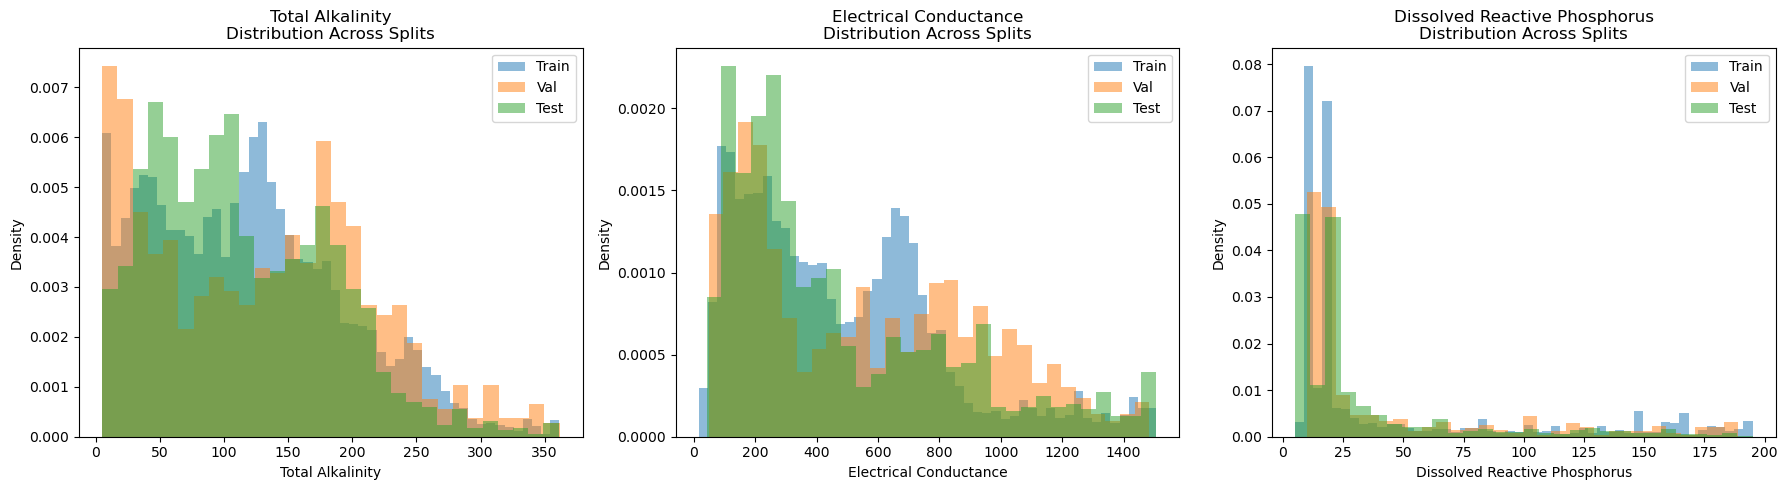

Target distribution plots saved as 'split_distributions.png'


In [15]:
# Verify target distributions are similar across splits
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

targets = ['Total Alkalinity', 'Electrical Conductance', 'Dissolved Reactive Phosphorus']

for i, target in enumerate(targets):
    axes[i].hist(df_train[target].dropna(), bins=50, alpha=0.5, label='Train', density=True)
    axes[i].hist(df_val[target].dropna(), bins=30, alpha=0.5, label='Val', density=True)
    axes[i].hist(df_test[target].dropna(), bins=30, alpha=0.5, label='Test', density=True)
    axes[i].set_xlabel(target)
    axes[i].set_ylabel('Density')
    axes[i].set_title(f'{target}\nDistribution Across Splits')
    axes[i].legend()

plt.tight_layout()
plt.savefig('split_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("Target distribution plots saved as 'split_distributions.png'")

Cell 7: Geographic Distribution Check

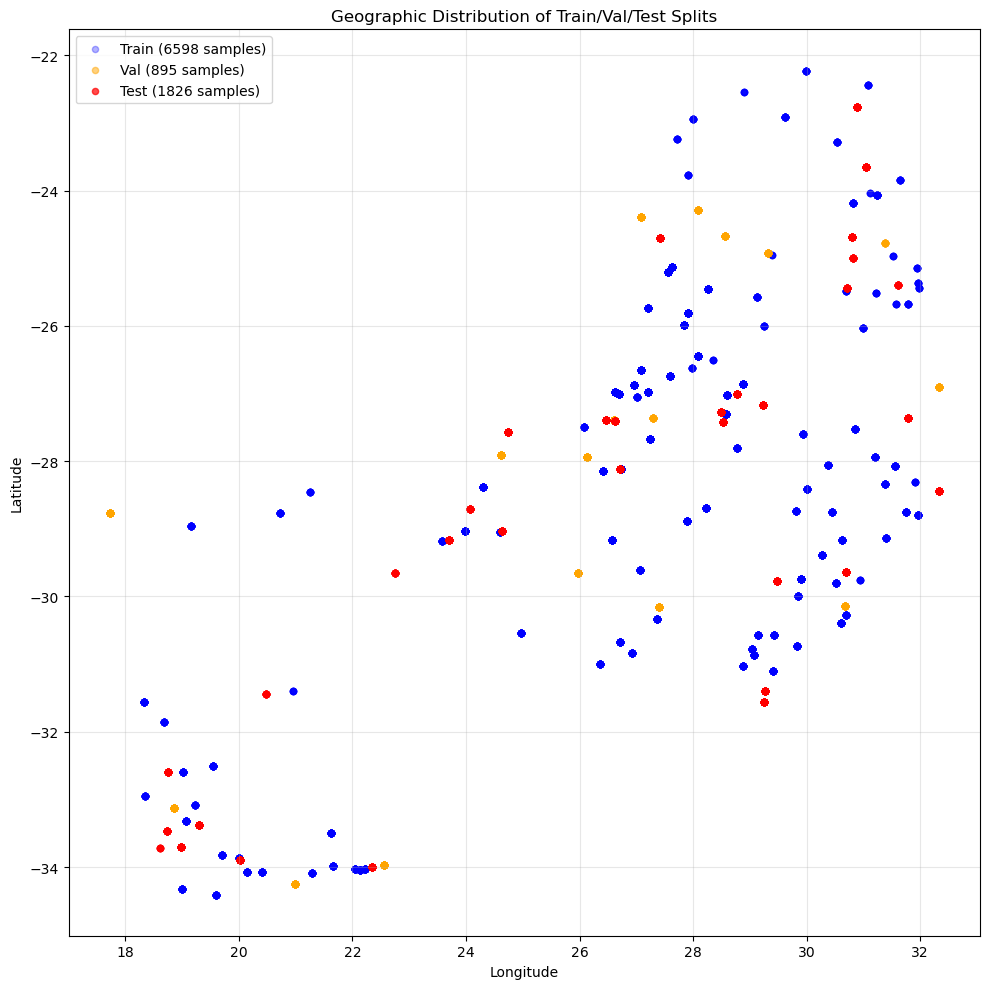

Geographic distribution plot saved as 'split_geography.png'


In [17]:
# Visualize geographic distribution of splits
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

ax.scatter(df_train['Longitude'], df_train['Latitude'], 
           c='blue', s=20, alpha=0.3, label=f'Train ({len(df_train)} samples)')
ax.scatter(df_val['Longitude'], df_val['Latitude'], 
           c='orange', s=20, alpha=0.5, label=f'Val ({len(df_val)} samples)')
ax.scatter(df_test['Longitude'], df_test['Latitude'], 
           c='red', s=20, alpha=0.7, label=f'Test ({len(df_test)} samples)')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Geographic Distribution of Train/Val/Test Splits')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('split_geography.png', dpi=150, bbox_inches='tight')
plt.show()

print("Geographic distribution plot saved as 'split_geography.png'")

Cell 8: Save Split Files

In [19]:
import base64
from IPython.display import HTML, display

# Save the three splits
print("="*80)
print("SAVING SPLIT FILES")
print("="*80)

# Save to CSV (for use in next notebooks)
df_train.to_csv('train70.csv', index=False)
df_val.to_csv('val10.csv', index=False)
df_test.to_csv('test20.csv', index=False)

print(f"\nSaved: train70.csv {df_train.shape}")
print(f"Saved: val10.csv {df_val.shape}")
print(f"Saved: test20.csv {df_test.shape}")

# Generate download links
print("\n" + "="*80)
print("DOWNLOAD LINKS")
print("="*80)

for fname, df_split in [("train70.csv", df_train),
                        ("val10.csv", df_val),
                        ("test20.csv", df_test)]:
    csv = df_split.to_csv(index=False)
    b64 = base64.b64encode(csv.encode()).decode()
    display(HTML(f'<a href="data:file/csv;base64,{b64}" '
                f'download="{fname}">Download {fname}</a>'))

SAVING SPLIT FILES

Saved: train70.csv (6598, 7)
Saved: val10.csv (895, 7)
Saved: test20.csv (1826, 7)

DOWNLOAD LINKS


Cell 9: Create Unique Extraction Lists

In [27]:
# Create lists of unique (lat, lon, date) combinations for feature extraction
# This is what you'll use in the next notebooks

# Combine all three splits to get ALL unique combinations
df_all = pd.concat([df_train, df_val, df_test], ignore_index=True)

# Unique (lat, lon, date) for time-varying features (TerraClimate, Landsat)
unique_samples = df_all[['Latitude', 'Longitude', 'Sample Date']].drop_duplicates()
unique_samples = unique_samples.sort_values(['Latitude', 'Longitude', 'Sample Date']).reset_index(drop=True)


print("UNIQUE EXTRACTION LISTS")
print("-"*80)
print(f"\nUnique (lat, lon, date) combinations: {len(unique_samples):,}")
print("  (Use this for TerraClimate and Landsat extraction)")

# Unique (lat, lon) for static features (Elevation, Land Cover)
unique_locations = df_all[['Latitude', 'Longitude']].drop_duplicates()
unique_locations = unique_locations.sort_values(['Latitude', 'Longitude']).reset_index(drop=True)

print(f"\nUnique (lat, lon) locations: {len(unique_locations):,}")
print("  (Use this for Elevation and Land Cover extraction)")

# Save these for reference in next notebooks
unique_samples.to_csv('unique_samples_for_extraction.csv', index=False)
unique_locations.to_csv('unique_locations_for_extraction.csv', index=False)

print(f"\nSaved: unique_samples_for_extraction.csv")
print(f"Saved: unique_locations_for_extraction.csv")

# Generate download links

for fname, df_unique in [("unique_samples_for_extraction.csv", unique_samples),
                         ("unique_locations_for_extraction.csv", unique_locations)]:
    csv = df_unique.to_csv(index=False)
    b64 = base64.b64encode(csv.encode()).decode()
    display(HTML(f'<a href="data:file/csv;base64,{b64}" '
                f'download="{fname}">Download {fname}</a>'))

UNIQUE EXTRACTION LISTS
--------------------------------------------------------------------------------

Unique (lat, lon, date) combinations: 9,319
  (Use this for TerraClimate and Landsat extraction)

Unique (lat, lon) locations: 162
  (Use this for Elevation and Land Cover extraction)

Saved: unique_samples_for_extraction.csv
Saved: unique_locations_for_extraction.csv
